In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report


In [3]:
from scipy.io import arff
import pandas as pd

# Path to your file (relative path — IMPORTANT for grading)
path = "../data/raw/mammography.arff"

# Load ARFF file
data, meta = arff.loadarff(path)

# Convert to DataFrame
df = pd.DataFrame(data)

# Preview
df.head()

,attr1,attr2,attr3,attr4,attr5,attr6,class
0,0.230020,5.072578,-0.276061,0.832444,-0.377866,0.480322,b'-1'
1,0.155491,-0.169390,0.670652,-0.859553,-0.377866,-0.945723,b'-1'
2,-0.784415,-0.443654,5.674705,-0.859553,-0.377866,-0.945723,b'-1'
3,0.546088,0.131415,-0.456387,-0.859553,-0.377866,-0.945723,b'-1'
4,-0.102987,-0.394994,-0.140816,0.979703,-0.377866,1.013566,b'-1'


In [4]:
df['class'] = df['class'].str.decode('utf-8')

In [5]:
df['class'] = df['class'].astype(int)
df['class'] = df['class'].replace(-1, 0)

In [6]:
df.to_csv("../data/processed/mammography.csv", index=False)
print("Saved successfully!")

Saved successfully!


In [7]:
print(df['class'].value_counts())

class
0    10923
1      260
Name: count, dtype: int64


In [8]:
df = pd.read_csv("../data/processed/mammography.csv")
df.columns

Index(['attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6', 'class'], dtype='object')

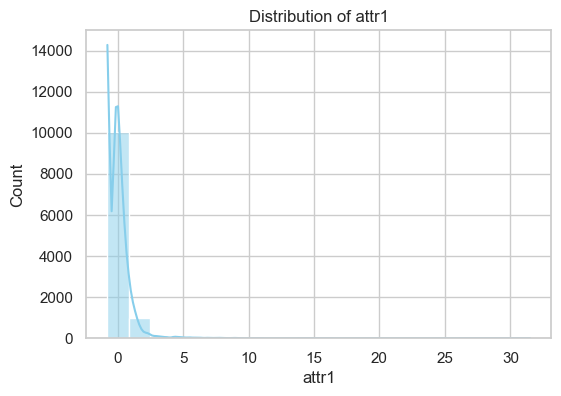

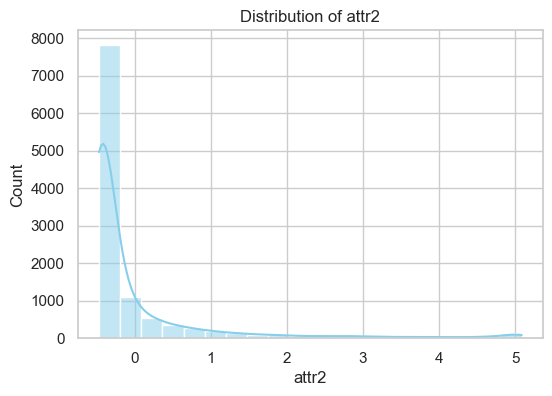

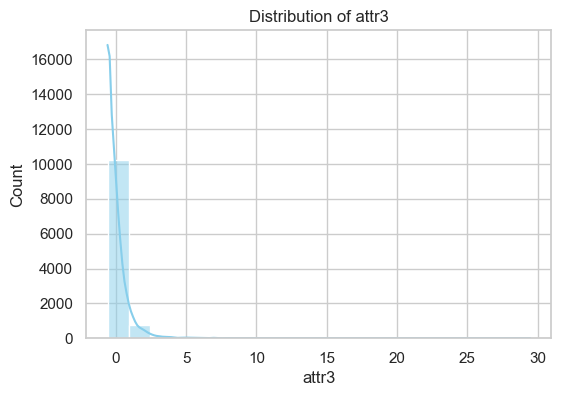

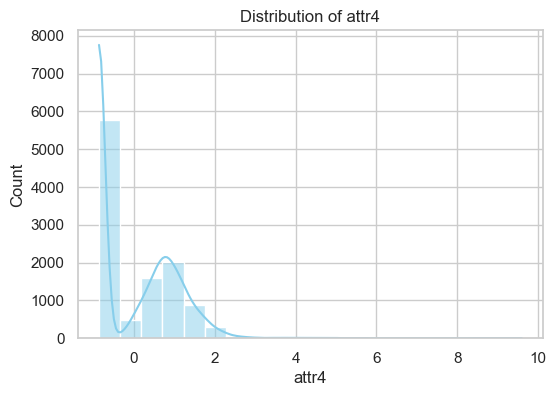

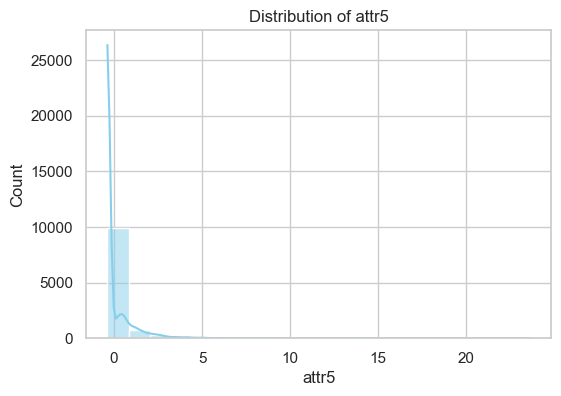

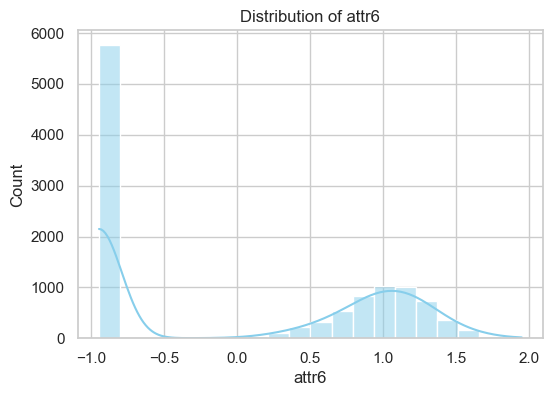

In [9]:
sns.set(style = "whitegrid")

continuous_features = ['attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6']
target = 'class'
#plot the historgrams for continous features 
for col in continuous_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

C:\Users\patrusgurung\AppData\Local\Temp\ipykernel_19088\4008742577.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target, data= df, palette = "Set2" )


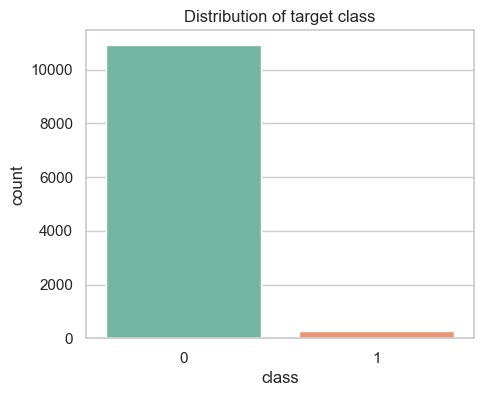

In [10]:
#plotting the target distrbution 
plt.figure(figsize=(5,4))
sns.countplot(x=target, data= df, palette = "Set2" )
plt.title('Distribution of target class')
plt.xlabel("class")
plt.ylabel("count")
plt.show()

In [11]:
#defining the numerical and categorical features 
X = df.drop('class', axis =1)
y = df['class']

#identify numerical and categoricla columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_fetures = X.select_dtypes(include= ['object']).columns.tolist()

In [12]:
#spliting into training and testing data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}") 

Training samples: 8946, Test samples: 2237


In [13]:
#building Column transformer 
#datasets has no any categorical featires so i have not put the categoraical value 
numeric_features = X_train.columns.tolist()
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features)
    ]
)



In [14]:
#building the pipeline 
baseline_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier( random_state=42, n_jobs=-1))

])

#evaluatin the CV 5 fold 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use F1 score since dataset is imbalanced
baseline_scores = cross_val_score(
    baseline_pipeline, X_train, y_train, cv=cv, scoring='f1'
)

print("5-Fold CV F1 scores:", baseline_scores)
print("Mean F1 score:      ", baseline_scores.mean().round(4))
print("Std F1 score:       ", baseline_scores.std().round(4))

5-Fold CV F1 scores: [0.68571429 0.64615385 0.71875    0.63636364 0.66666667]
Mean F1 score:       0.6707
Std F1 score:        0.0294


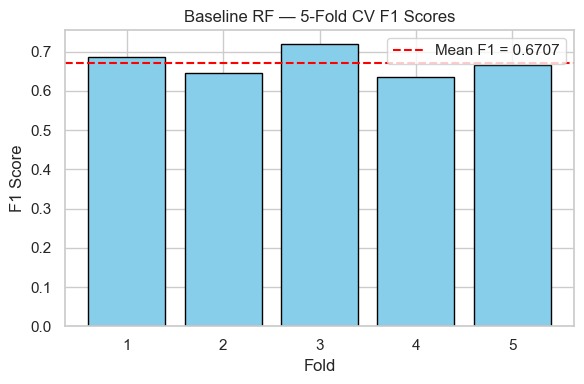

In [15]:
# --- Visualize CV scores ---
plt.figure(figsize=(6, 4))
plt.bar(range(1, 6), baseline_scores, color='skyblue', edgecolor='black')
plt.axhline(baseline_scores.mean(), color='red', linestyle='--',
            label=f'Mean F1 = {baseline_scores.mean():.4f}')
plt.title("Baseline RF — 5-Fold CV F1 Scores")
plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.legend()
plt.tight_layout()
plt.show()

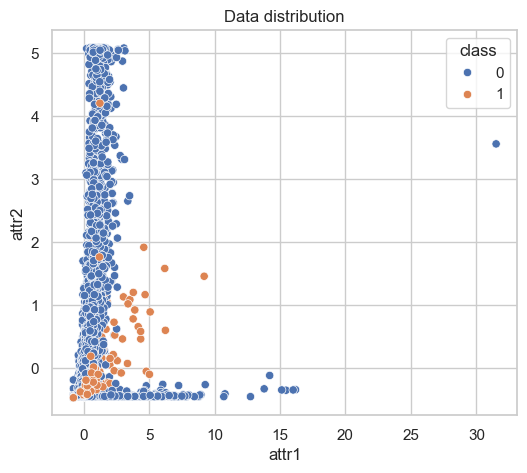

c:\Users\patrusgurung\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


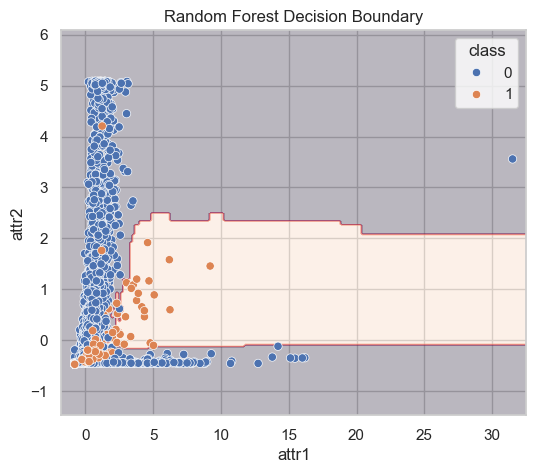

In [16]:
#visualize the datapoinst s
feat1 = numeric_features[0]
feat2 = numeric_features[1]
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x=feat1, y=feat2, hue='class')
plt.title('Data distribution')
plt.show()

#train random forest on 2 features 
X_vis = df[[feat1, feat2]]
y_vis = df['class']

model = RandomForestClassifier(random_state=42)
model.fit(X_vis, y_vis)

# Create grid
x_min, x_max = X_vis[feat1].min() - 1, X_vis[feat1].max() + 1
y_min, y_max = X_vis[feat2].min() - 1, X_vis[feat2].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Predict on grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3)
sns.scatterplot(x=X_vis[feat1], y=X_vis[feat2], hue=y_vis)

plt.title("Random Forest Decision Boundary")
plt.show()

In [17]:
#hyperparameter 
param_grid = {
    'classifier__n_estimators' : [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2,5],
    'classifier__min_samples_leaf': [1,2]
}



In [19]:


#Grid Search 
grid_search = GridSearchCV(
    baseline_pipeline,
    param_grid,
    cv=cv,
    scoring = 'f1',
    n_jobs = -1
)


grid_search.fit(X_train, y_train)

print("Best F1 score (tuned)  :", round(grid_search.best_score_, 4))
print("Best F1 score (baseline):", round(baseline_scores.mean(), 4))
print("Best hyperparameters   :", grid_search.best_params_)

Best F1 score (tuned)  : 0.6707
Best F1 score (baseline): 0.6707
Best hyperparameters   : {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}



Improvement over baseline: +0.0000


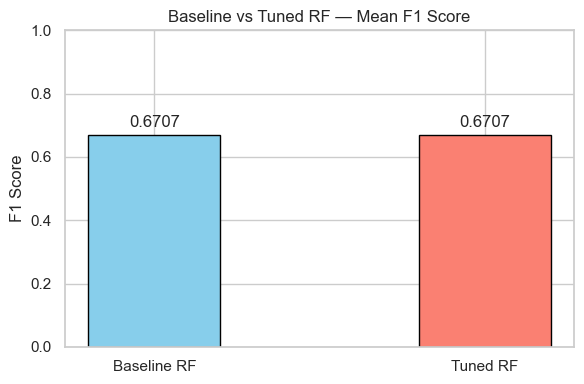

In [21]:
improvement = grid_search.best_score_ - baseline_scores.mean()
print(f"\nImprovement over baseline: {improvement:+.4f}")

models = ['Baseline RF', 'Tuned RF']
scores = [baseline_scores.mean(), grid_search.best_score_]

plt.figure(figsize=(6, 4))
bars = plt.bar(models, scores, color=['skyblue', 'salmon'], edgecolor='black', width=0.4)
plt.bar_label(bars, fmt='%.4f', padding=3)
plt.title("Baseline vs Tuned RF — Mean F1 Score")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

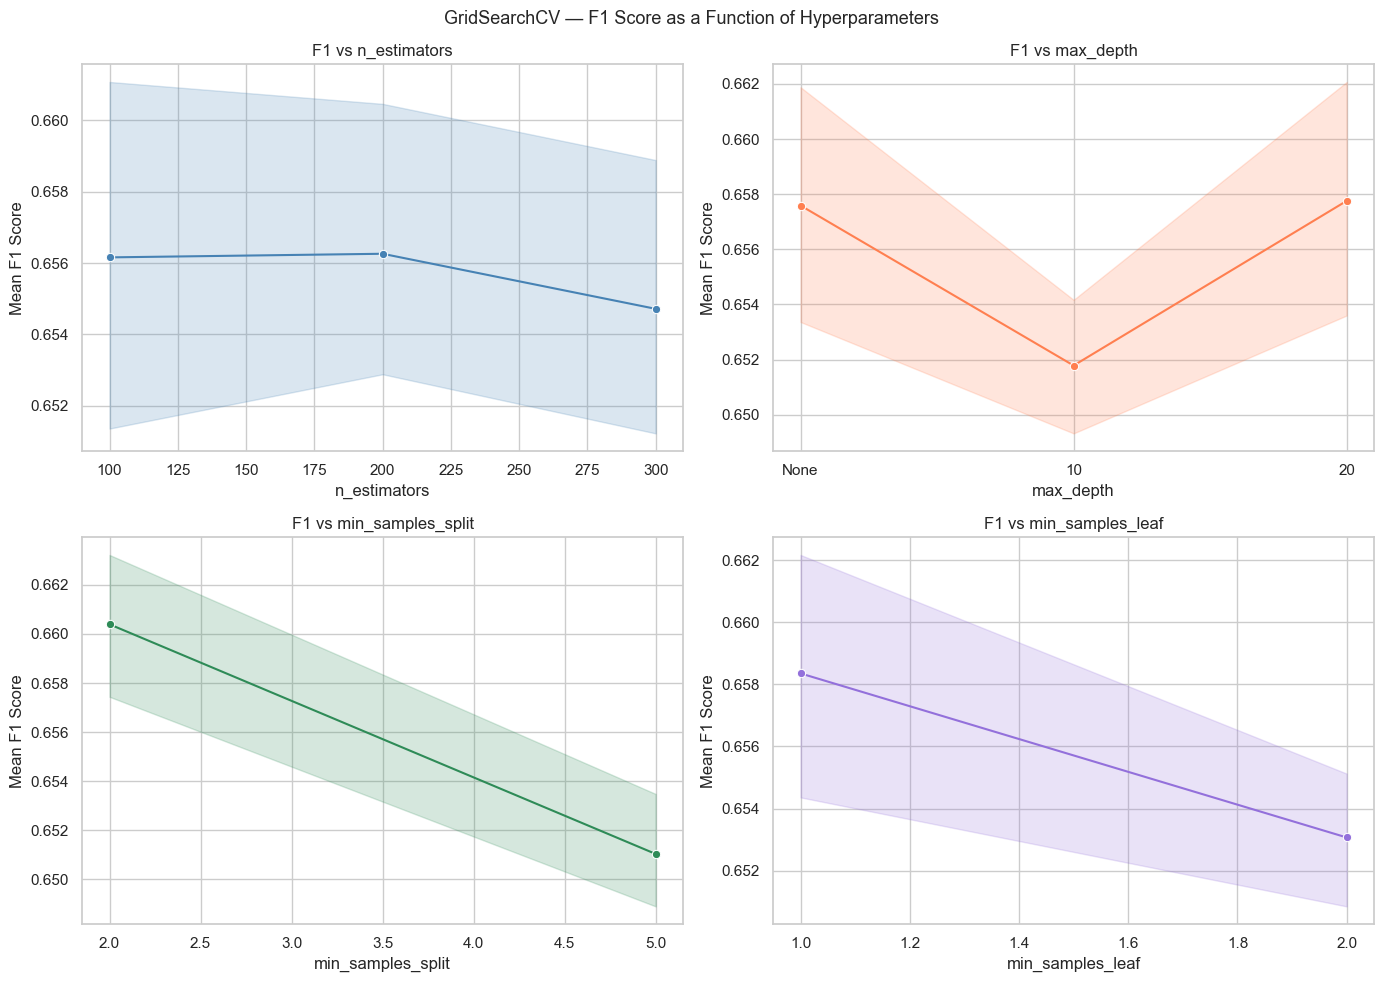

In [22]:
# Visualization 2 — F1 as a function of hyperparameters
# =============================================================================
results = pd.DataFrame(grid_search.cv_results_)

# convert None to string for plotting
results['param_classifier__max_depth'] = results[
    'param_classifier__max_depth'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 — F1 vs n_estimators
sns.lineplot(
    data    = results,
    x       = 'param_classifier__n_estimators',
    y       = 'mean_test_score',
    marker  = 'o',
    color   = 'steelblue',
    ax      = axes[0, 0]
)
axes[0, 0].set_title("F1 vs n_estimators")
axes[0, 0].set_xlabel("n_estimators")
axes[0, 0].set_ylabel("Mean F1 Score")

# Plot 2 — F1 vs max_depth
sns.lineplot(
    data    = results,
    x       = 'param_classifier__max_depth',
    y       = 'mean_test_score',
    marker  = 'o',
    color   = 'coral',
    ax      = axes[0, 1]
)
axes[0, 1].set_title("F1 vs max_depth")
axes[0, 1].set_xlabel("max_depth")
axes[0, 1].set_ylabel("Mean F1 Score")

# Plot 3 — F1 vs min_samples_split
sns.lineplot(
    data    = results,
    x       = 'param_classifier__min_samples_split',
    y       = 'mean_test_score',
    marker  = 'o',
    color   = 'seagreen',
    ax      = axes[1, 0]
)
axes[1, 0].set_title("F1 vs min_samples_split")
axes[1, 0].set_xlabel("min_samples_split")
axes[1, 0].set_ylabel("Mean F1 Score")

# Plot 4 — F1 vs min_samples_leaf
sns.lineplot(
    data    = results,
    x       = 'param_classifier__min_samples_leaf',
    y       = 'mean_test_score',
    marker  = 'o',
    color   = 'mediumpurple',
    ax      = axes[1, 1]
)
axes[1, 1].set_title("F1 vs min_samples_leaf")
axes[1, 1].set_xlabel("min_samples_leaf")
axes[1, 1].set_ylabel("Mean F1 Score")

plt.suptitle("GridSearchCV — F1 Score as a Function of Hyperparameters", fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
#task d KFold vs StratifiedKfold + sensitivuty analysis 
# --- 1. KFold with shuffling (default seed) ---
cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search_kfold = GridSearchCV(
    baseline_pipeline, param_grid,
    cv=cv_kfold, scoring='f1', n_jobs=-1
)
grid_search_kfold.fit(X_train, y_train)

print("=" * 55)
print("StratifiedKFold — Best Params:", grid_search.best_params_)
print("StratifiedKFold — Best F1    :", round(grid_search.best_score_, 4))
print("-" * 55)
print("KFold           — Best Params:", grid_search_kfold.best_params_)
print("KFold           — Best F1    :", round(grid_search_kfold.best_score_, 4))
print("=" * 55)

# --- 2. Sensitivity to KFold shuffle random seed ---
print("\n--- KFold: varying shuffle random_state ---")
kfold_seed_results = []

for seed in [0, 7, 21, 42, 99]:
    cv_test = KFold(n_splits=5, shuffle=True, random_state=seed)
    gs = GridSearchCV(
        baseline_pipeline, param_grid,
        cv=cv_test, scoring='f1', n_jobs=-1
    )
    gs.fit(X_train, y_train)
    kfold_seed_results.append({
        'shuffle_seed' : seed,
        'best_f1'      : round(gs.best_score_, 4),
        'n_estimators' : gs.best_params_['classifier__n_estimators'],
        'max_depth'    : gs.best_params_['classifier__max_depth'],
        'min_split'    : gs.best_params_['classifier__min_samples_split'],
        'min_leaf'     : gs.best_params_['classifier__min_samples_leaf'],
    })
    print(f"  Seed={seed:3d} | F1={gs.best_score_:.4f} | Params: {gs.best_params_}")

df_seed = pd.DataFrame(kfold_seed_results)

StratifiedKFold — Best Params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
StratifiedKFold — Best F1    : 0.6707
-------------------------------------------------------
KFold           — Best Params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
KFold           — Best F1    : 0.6743

--- KFold: varying shuffle random_state ---
  Seed=  0 | F1=0.6655 | Params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}
  Seed=  7 | F1=0.6679 | Params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
  Seed= 21 | F1=0.6771 | Params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_

In [26]:
#task e Weighted Random forest with Stratified 5 fold CV 
#weighted pipeline 
weighted_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', StandardScaler(), numeric_features)
    ])),
    ('classfier', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
weighted_scores= cross_val_score(
    weighted_pipeline,X_train, y_train, cv=cv, scoring='f1'
)
print("Weighted RF — 5-Fold CV F1 scores:", weighted_scores)
print("Weighted RF — Mean F1            :", round(weighted_scores.mean(), 4))
print("Baseline RF — Mean F1            :", round(baseline_scores.mean(), 4))
print(f"Improvement                      : {weighted_scores.mean() - baseline_scores.mean():+.4f}")

Weighted RF — 5-Fold CV F1 scores: [0.59701493 0.64615385 0.61290323 0.63636364 0.625     ]
Weighted RF — Mean F1            : 0.6235
Baseline RF — Mean F1            : 0.6707
Improvement                      : -0.0472


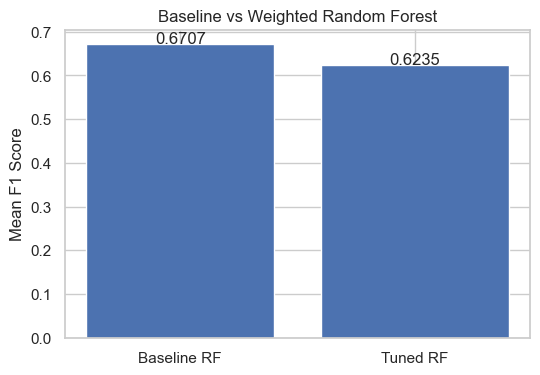

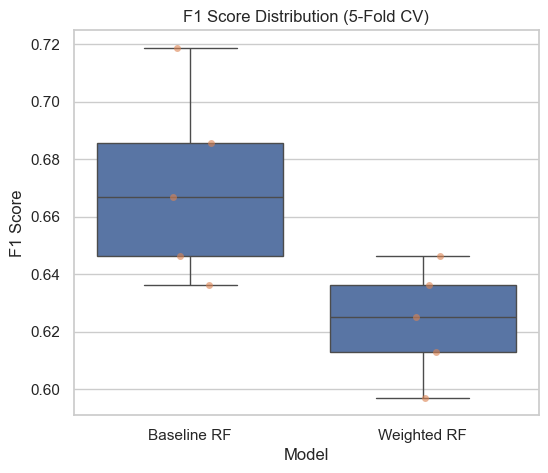

In [28]:
models1= ['Baseline RF', 'Weighted RF']
means = [baseline_scores.mean(), weighted_scores.mean()]
plt.figure(figsize=(6,4))
plt.bar(models, means)
plt.ylabel("Mean F1 Score")
plt.title("Baseline vs Weighted Random Forest")

# annotate values
for i, v in enumerate(means):
    plt.text(i, v + 0.002, f"{v:.4f}", ha='center')

plt.show()

# combine scores into dataframe
df_scores = pd.DataFrame({
    'Baseline RF': baseline_scores,
    'Weighted RF': weighted_scores
})

# reshape for seaborn
df_melted = df_scores.melt(var_name='Model', value_name='F1 Score')

plt.figure(figsize=(6,5))
sns.boxplot(data=df_melted, x='Model', y='F1 Score')
sns.stripplot(data=df_melted, x='Model', y='F1 Score', jitter=True, alpha=0.6)

plt.title("F1 Score Distribution (5-Fold CV)")
plt.show()

##TASKf SMOTE and Random Undersampling with Startified 5 fold CV 


In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- 1. SMOTE Pipeline ---
# ImbPipeline is used instead of Pipeline so SMOTE is applied
# only on training folds, not validation folds (prevents data leakage)
smote_pipeline = ImbPipeline([
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', StandardScaler(), numeric_features)
    ])),
    ('smote',      SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

smote_scores = cross_val_score(
    smote_pipeline, X_train, y_train, cv=cv, scoring='f1'
)

print("SMOTE RF — 5-Fold CV F1 scores:", smote_scores)
print("SMOTE RF — Mean F1            :", round(smote_scores.mean(), 4))

#2 Random Undersampling Pipeline
under_pipeline = ImbPipeline([
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', StandardScaler(), numeric_features)
    ])),
    ('undersample', RandomUnderSampler(random_state=42)),
    ('classifier',  RandomForestClassifier(random_state=42, n_jobs=-1))
])
under_scores= cross_val_score(
    under_pipeline,X_train, y_train
, cv=cv, scoring='f1')

print("\nUndersampling RF — 5-Fold CV F1 scores:", under_scores)
print("Undersampling RF — Mean F1            :", round(under_scores.mean(), 4))

SMOTE RF — 5-Fold CV F1 scores: [0.61261261 0.55670103 0.65979381 0.5625     0.62626263]
SMOTE RF — Mean F1            : 0.6036

Undersampling RF — 5-Fold CV F1 scores: [0.33928571 0.3125     0.30452675 0.30088496 0.31818182]
Undersampling RF — Mean F1            : 0.3151


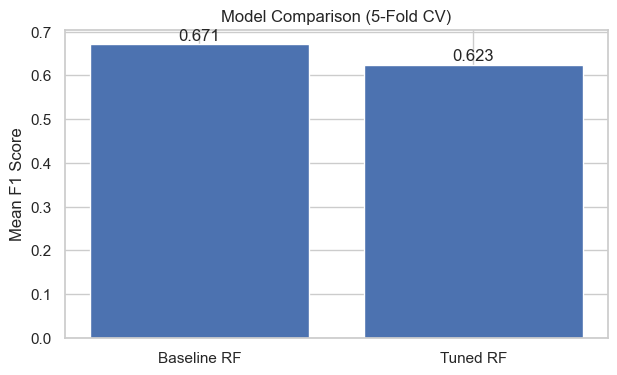

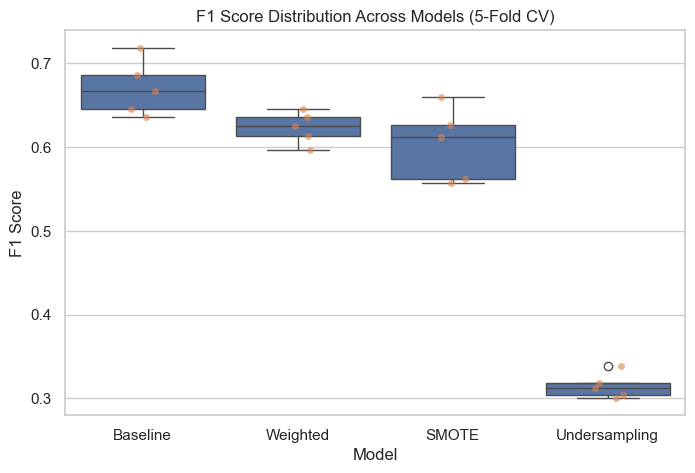

In [32]:
#visualization of all models comparison
model2= ['baseline', 'weighted', 'SMOTE', 'Undersampling']
means2= [baseline_scores.mean(),
    weighted_scores.mean(),
    smote_scores.mean(),
    under_scores.mean()]
plt.figure(figsize=(7,4))
plt.bar(models, means)
plt.ylabel("Mean F1 Score")
plt.title("Model Comparison (5-Fold CV)")

# annotate values
for i, v in enumerate(means):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.show()

#box plot best visulaization
df_scores = pd.DataFrame({
    'Baseline': baseline_scores,
    'Weighted': weighted_scores,
    'SMOTE': smote_scores,
    'Undersampling': under_scores
})

df_melted = df_scores.melt(var_name='Model', value_name='F1 Score')

plt.figure(figsize=(8,5))
sns.boxplot(data=df_melted, x='Model', y='F1 Score')
sns.stripplot(data=df_melted, x='Model', y='F1 Score', 
              jitter=True, alpha=0.6)

plt.title("F1 Score Distribution Across Models (5-Fold CV)")
plt.show()

In [ ]:
#fir each model first 
baseline_pipeline.fit(X_train, y_train)
weighted_pipeline.fit(X_train, y_train)
smote_pipeline.fit(X_train, y_train)
under_pipeline.fit(X_train, y_train)

print("=" * 55)
print("BASELINE RF")
print("=" * 55)
print(classification_report(y_test, baseline_pipeline.predict(X_test)))

print("=" * 55)
print("WEIGHTED RF")
print("=" * 55)
print(classification_report(y_test, weighted_pipeline.predict(X_test)))

print("=" * 55)
print("SMOTE RF")
print("=" * 55)
print(classification_report(y_test, smote_pipeline.predict(X_test)))

print("=" *55)
print("UnderSample")
print("=" *55)
print(classification_report(y_test, under_pipeline.predict(X_test)))